# Final Project

## Import

In [151]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import statistics as st

## Dataset exploration

In [152]:
df = pd.read_csv('wfp-hungermap-data-for-mdg.csv')
print(df.shape)
df.head()

(1382, 15)


,countrycode,countryname,adminone,adminlevel,population,date,datatype,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,#country+code,#country+name,#adm1+name,#meta+adminlevel,#population+total,#date,#data+type,#population+fcs,#indicator+fcs+prevalence,#population+rcsi,#indicator+rcsi+prevalence,#population+health_access,#indicator+health_access+prevalence,#population+market_access,#indicator+market_access+prevalence
1,MDG,Madagascar,NaN,national,NaN,2024-03-04,SURVEY,8456947,0.32215332807656305,7816509,0.2977569119407755,2155430,0.08210751797908643,3180077,0.12113974014886676
2,MDG,Madagascar,NaN,national,NaN,2024-03-03,SURVEY,8604019,0.32775579126651516,7708249,0.2936329211224791,2185552,0.08325496662992705,3222276,0.1227472490461335
3,MDG,Madagascar,NaN,national,NaN,2024-03-02,SURVEY,8654571,0.3296814856147151,7845463,0.29885986642190426,2227397,0.08484898329823913,3284548,0.12511939962610666
4,MDG,Madagascar,NaN,national,NaN,2024-03-01,SURVEY,8597649,0.327513141248951,7748351,0.2951605462736907,2175090,0.08285642813079001,3330646,0.12687541988738874


In [153]:
# Remove the first column, it seems to be useless
df = df.loc[1:,:]
print(df.shape)
df.head()

(1381, 15)


,countrycode,countryname,adminone,adminlevel,population,date,datatype,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
1,MDG,Madagascar,NaN,national,NaN,2024-03-04,SURVEY,8456947,0.32215332807656305,7816509,0.2977569119407755,2155430,0.08210751797908643,3180077,0.12113974014886676
2,MDG,Madagascar,NaN,national,NaN,2024-03-03,SURVEY,8604019,0.32775579126651516,7708249,0.2936329211224791,2185552,0.08325496662992705,3222276,0.1227472490461335
3,MDG,Madagascar,NaN,national,NaN,2024-03-02,SURVEY,8654571,0.3296814856147151,7845463,0.29885986642190426,2227397,0.08484898329823913,3284548,0.12511939962610666
4,MDG,Madagascar,NaN,national,NaN,2024-03-01,SURVEY,8597649,0.327513141248951,7748351,0.2951605462736907,2175090,0.08285642813079001,3330646,0.12687541988738874
5,MDG,Madagascar,NaN,national,NaN,2024-02-29,SURVEY,8578497,0.3267835776576483,7827478,0.29817475775494634,2126254,0.08099610787983365,3322466,0.12656381292549368


In [154]:
# Statistiques
df.describe()

,countrycode,countryname,adminone,adminlevel,population,date,datatype,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
count,1381,1381,1320,1381,1320,1381,1381,1381,1381,1381,1381,1381,1381,1381,1381
unique,1,1,22,2,22,61,1,1002,1004,1005,1006,999,1002,997,1001
top,MDG,Madagascar,Alaotra Mangoro,subnational,1234447,2024-03-04,SURVEY,261716,0.21036792442972235,276340,0.24679253440656962,63114,0.05441267097571896,119124,0.05908185729680621
freq,1381,1381,60,1320,60,23,1381,8,8,8,8,8,8,8,8


countrycode and countryname have a unique value, we are studying data from a single country = Madagascar.
Same for datatype, it's always a SURVEY.

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1381 entries, 1 to 1381
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   countrycode               1381 non-null   object
 1   countryname               1381 non-null   object
 2   adminone                  1320 non-null   object
 3   adminlevel                1381 non-null   object
 4   population                1320 non-null   object
 5   date                      1381 non-null   object
 6   datatype                  1381 non-null   object
 7   fcs people                1381 non-null   object
 8   fcs prevalence            1381 non-null   object
 9   rcsi people               1381 non-null   object
 10  rcsi prevalence           1381 non-null   object
 11  health access people      1381 non-null   object
 12  health access prevalence  1381 non-null   object
 13  market access people      1381 non-null   object
 14  market access prevalence

We can see that almost all columns are non-zero, except for adminone and population.

All types ar object, we going to adapt the type automatically

In [156]:
# Categoricals columns 
text_cols = ['countrycode', 'countryname', 'adminone', 'adminlevel', 'date', 'datatype']

# Numericals columns 
numeric_cols = [col for col in df.columns if col not in text_cols]

# Convert
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df.dtypes

countrycode                  object
countryname                  object
adminone                     object
adminlevel                   object
population                  float64
date                         object
datatype                     object
fcs people                    int64
fcs prevalence              float64
rcsi people                   int64
rcsi prevalence             float64
health access people          int64
health access prevalence    float64
market access people          int64
market access prevalence    float64
dtype: object

### NaN Managment

In [157]:
df.isna().sum()

countrycode                  0
countryname                  0
adminone                    61
adminlevel                   0
population                  61
date                         0
datatype                     0
fcs people                   0
fcs prevalence               0
rcsi people                  0
rcsi prevalence              0
health access people         0
health access prevalence     0
market access people         0
market access prevalence     0
dtype: int64

We can see that nothing has changed, so the errors were handled correctly during the conversion.

For numerical columns, we are going to use KNNImputer.

In [158]:
def replace_NaN(df, columns):
    imputer = KNNImputer(n_neighbors = 4, weights = 'uniform')
    df_no_nan = imputer.fit_transform(df[columns])
    df[columns] = pd.DataFrame(df_no_nan, columns = columns)
    return df

In [159]:
df = replace_NaN(df, ['population'])
df.isna().sum()

countrycode                  0
countryname                  0
adminone                    61
adminlevel                   0
population                   1
date                         0
datatype                     0
fcs people                   0
fcs prevalence               0
rcsi people                  0
rcsi prevalence              0
health access people         0
health access prevalence     0
market access people         0
market access prevalence     0
dtype: int64

## Using a modified Z-Score transformation for outlier detection

In [160]:
def mad_z_score(tab):
  outliers = []
  mad = st.median([abs(val - st.median(tab)) for val in tab])
  for val in tab:
    if mad == 0:
      m = 0
    else :
      m = (0.6745 * (val - st.median(tab)))/mad
    if m > 3.5 : outliers.append(val)

  return outliers

In [161]:
for col in numeric_cols:
    outliers = mad_z_score(df[col])
    print(f"Outliers for {col} ({len(outliers)}): ", outliers)

Outliers for population (60):  [4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0, 4024795.0]
Outliers for fcs people (69):  [8456947, 8604019, 8654571, 8597649, 8578497, 8510050, 8405820, 8464145, 8465539, 8467393, 8494808, 8480651, 8512559, 8668480, 8800342, 8779954, 8822817, 8765712, 8833771, 8948223, 8870512, 8937443, 9041255, 9146080, 9131984, 9138997, 8977165, 9042455, 8925665, 8890073, 894269

This seems to be a lot. We can see many values close to each other, which is not necessarily an outlier.

## Feature selection
| Colonne                | Description courte                                                      |
|------------------------|------------------------------------------------------------------------|
| countrycode            | Code du pays (souvent un code ISO ou un code standard pour pays)       |
| countryname            | Nom complet du pays                                                    |
| adminone               | Niveau administratif supérieur        |
| adminlevel             | Niveau administratif (indique le rang hiérarchique de adminone)       |
| population             | Population locale     |
| date                   | Date de la donnée           |
| datatype               | Type de données (nature des indicateurs mesurés)                       |
| fcs people             | Nombre de personnes concernées par la "FCS" (peut être Food Consumption Score ou autre indicateur) |
| fcs prevalence         | Prévalence ou proportion liée au FCS                                  |
| rcsi people            | Nombre de personnes concernées par le "RCSI" (peut être Reduced Coping Strategy Index ou autre indicateur) |
| rcsi prevalence        | Prévalence ou proportion liée au RCSI                                 |
| health access people   | Nombre de personnes ayant accès aux soins de santé                      |
| health access prevalence| Prévalence ou proportion de l'accès aux soins de santé                 |
| market access people   | Nombre de personnes ayant accès aux marchés                            |
| market access prevalence| Prévalence ou proportion de l'accès aux marchés                        |

We can see that countrycode and countryname are redundant, so we will keep countryname, as it is clearer.
We have also seen that datatype is always SURVEY, so we don't need it.

In [162]:
df.drop(columns=['countrycode', 'datatype'], inplace=True)
df.columns

Index(['countryname', 'adminone', 'adminlevel', 'population', 'date',
       'fcs people', 'fcs prevalence', 'rcsi people', 'rcsi prevalence',
       'health access people', 'health access prevalence',
       'market access people', 'market access prevalence'],
      dtype='object')

Let's create the correlation matrix to see which columns are relevant.

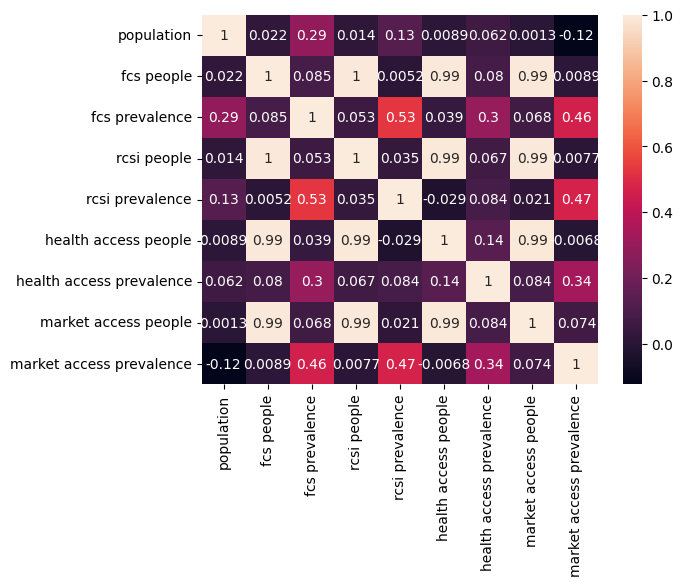

In [163]:
text_cols = ['countryname', 'adminone', 'adminlevel', 'date']
numeric_cols = [col for col in df.columns if col not in text_cols]
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot = True)
plt.show()

#### Correlation Matrix Analysis

**Critical Multicollinearity**
- Perfect correlations (r=0.99) between all `*_people` variables
- These 4 variables are redundant with each other

**Recommendation**
Keep only one `*_people` variable and remove the other 3

Keep all `*_prevalence` variables:
- Moderate correlations are acceptable (0.34-0.53)

Keep `population`:
- Low correlations with other variables (<0.3)
- Independent information

**Final Features**
`population`, `fcs_people`, `fcs_prevalence`, `rcsi_prevalence`, `health_access_prevalence`, `market_access_prevalence`